In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from collections import Counter
import seaborn as sns

In [2]:
DATASET_PATH = '/work/datasets/asl_alphabet_train'

In [3]:
# Анализ классов и изображений
class_info = {}

IGNORE_FOLDERS = {'.ipynb_checkpoints', '.DS_Store', '__pycache__', '.git'}

for class_name in sorted(os.listdir(DATASET_PATH)):
    class_path = os.path.join(DATASET_PATH, class_name)
    
    # Пропустить скрытые папки и не-папки
    if not os.path.isdir(class_path):
        continue
    if class_name in IGNORE_FOLDERS:
        continue
    if class_name.startswith('.'):  # Все скрытые папки
        continue
    
    images = [f for f in os.listdir(class_path) 
              if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))]
    
    # Размеры изображений
    sizes = []
    for img_file in images[:10]:  # Проверить первые 10
        img_path = os.path.join(class_path, img_file)
        with Image.open(img_path) as img:
            sizes.append(img.size)
    
    class_info[class_name] = {
        'count': len(images),
        'sizes': sizes
    }

# Вывод статистики
counts = {k: v['count'] for k, v in class_info.items()}
print('=' * 50)
print(f'Всего классов: {len(class_info)}')
print(f'Всего изображений: {sum(counts.values())}')
print(f'Минимум в классе: {min(counts.values())} ({min(counts, key=counts.get)})')
print(f'Максимум в классе: {max(counts.values())} ({max(counts, key=counts.get)})')
print(f'Среднее: {np.mean(list(counts.values())):.0f}')
print('=' * 50)
print('\nКоличество по классам:')
for class_name, count in sorted(counts.items()):
    bar = '█' * (count // 100)
    print(f'  {class_name}: {count:5d} {bar}')


Всего классов: 28
Всего изображений: 216238
Минимум в классе: 3030 (nothing)
Максимум в классе: 8458 (A)
Среднее: 7723

Количество по классам:
  A:  8458 ████████████████████████████████████████████████████████████████████████████████████
  B:  8309 ███████████████████████████████████████████████████████████████████████████████████
  C:  8146 █████████████████████████████████████████████████████████████████████████████████
  D:  7629 ████████████████████████████████████████████████████████████████████████████
  E:  7744 █████████████████████████████████████████████████████████████████████████████
  F:  8031 ████████████████████████████████████████████████████████████████████████████████
  G:  7844 ██████████████████████████████████████████████████████████████████████████████
  H:  7906 ███████████████████████████████████████████████████████████████████████████████
  I:  7953 ███████████████████████████████████████████████████████████████████████████████
  J:  7503 █████████████████████

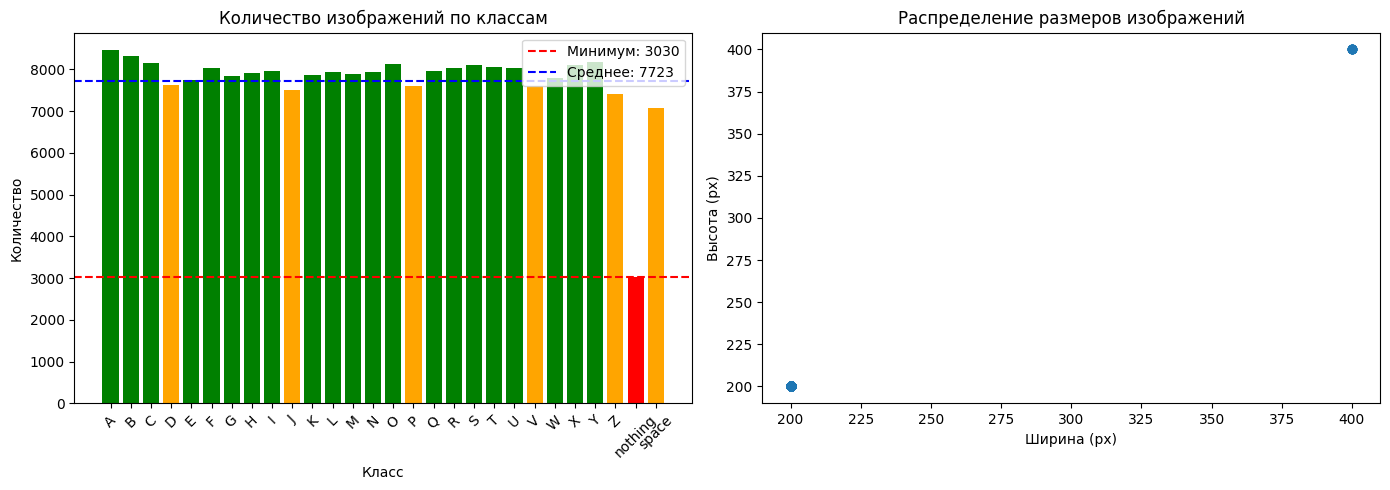

In [4]:

plt.figure(figsize=(14, 5))

# График количества по классам
plt.subplot(1, 2, 1)
classes = list(counts.keys())
values = list(counts.values())
colors = ['red' if v < np.mean(values) * 0.5 else 
          'orange' if v < np.mean(values) else 
          'green' for v in values]

plt.bar(classes, values, color=colors)
plt.axhline(y=min(values), color='red', 
            linestyle='--', label=f'Минимум: {min(values)}')
plt.axhline(y=np.mean(values), color='blue', 
            linestyle='--', label=f'Среднее: {np.mean(values):.0f}')
plt.title('Количество изображений по классам')
plt.xlabel('Класс')
plt.ylabel('Количество')
plt.legend()
plt.xticks(rotation=45)

# Гистограмма размеров
plt.subplot(1, 2, 2)
all_sizes = []
for info in class_info.values():
    all_sizes.extend(info['sizes'])

widths = [s[0] for s in all_sizes]
heights = [s[1] for s in all_sizes]
plt.scatter(widths, heights, alpha=0.5)
plt.title('Распределение размеров изображений')
plt.xlabel('Ширина (px)')
plt.ylabel('Высота (px)')

plt.tight_layout()
plt.show()


In [5]:
# Параметры
def get_classes(dataset_path):
    """Получить список классов без служебных папок"""
    return sorted([
        d for d in os.listdir(dataset_path)
        if os.path.isdir(os.path.join(dataset_path, d))
        and not d.startswith('.')          # Скрытые папки
        and d not in IGNORE_FOLDERS        # Служебные папки
    ])

classes = get_classes(DATASET_PATH)
print(f'Найдено классов: {len(classes)}')
print(f'Классы: {classes}')

TARGET_SIZE = (224, 224)      # Размер для ResNet
OUTPUT_PATH = '/work/datasets/tiny'

TARGET_COUNT = 500

print(f'Целевой размер изображений: {TARGET_SIZE}')
print(f'Целевое количество на класс: {TARGET_COUNT}')
print(f'Итого изображений: {TARGET_COUNT * len(class_info)}')


Найдено классов: 28
Классы: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'nothing', 'space']
Целевой размер изображений: (224, 224)
Целевое количество на класс: 500
Итого изображений: 14000


In [6]:
from PIL import Image, ImageEnhance, ImageFilter
import random
import shutil

def augment_image(img):
    """Случайная аугментация изображения"""
    augmentations = []
    
    # Случайный горизонтальный флип
    if random.random() > 0.5:
        img = img.transpose(Image.FLIP_LEFT_RIGHT)
        augmentations.append('flip')
    
    # Случайный поворот
    if random.random() > 0.5:
        angle = random.uniform(-15, 15)
        img = img.rotate(angle, fillcolor=(0, 0, 0))
        augmentations.append(f'rotate_{angle:.0f}')
        # Случайная яркость
    if random.random() > 0.5:
        factor = random.uniform(0.8, 1.2)
        img = ImageEnhance.Brightness(img).enhance(factor)
        augmentations.append('brightness')
    
    # Случайный контраст
    if random.random() > 0.5:
        factor = random.uniform(0.8, 1.2)
        img = ImageEnhance.Contrast(img).enhance(factor)
        augmentations.append('contrast')
    
    # Случайный зум (кроп)
    if random.random() > 0.5:
        w, h = img.size
        crop = random.uniform(0.1, 0.2)
        left   = int(w * crop)
        top    = int(h * crop)
        right  = int(w * (1 - crop))
        bottom = int(h * (1 - crop))
        img = img.crop((left, top, right, bottom))
        augmentations.append('zoom')
    
    return img

In [7]:
from tqdm import tqdm

def process_dataset(dataset_path, output_path, 
                    target_size, target_count):
    
    os.makedirs(output_path, exist_ok=True)
    
    stats = {'processed': 0, 'augmented': 0, 'skipped': 0}
    
    classes = sorted([
        d for d in os.listdir(dataset_path)
        if os.path.isdir(os.path.join(dataset_path, d))
        and not d.startswith('.')
        and d not in IGNORE_FOLDERS
    ])
    
    
    for class_name in classes:
        class_input  = os.path.join(dataset_path, class_name)
        class_output = os.path.join(output_path, class_name)
        os.makedirs(class_output, exist_ok=True)
    
        # Список изображений
        images = [f for f in os.listdir(class_input) 
              if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))]
    
        current_count = len(images)
        saved_count = 0
    
        print(f'\nКласс {class_name}: {current_count} → {target_count}')
    
        # Сортировать для стабильного порядка
        images.sort()
    
        # === УМЕНЬШЕНИЕ (если изображений больше нужного) ===
        if current_count >= target_count:
            # Вычислить шаг для равномерного прореживания
            step = current_count / target_count
            selected = [images[int(i * step)] for i in range(target_count)]
        
            for idx, img_file in enumerate(tqdm(selected, 
                                            desc=f'  Обработка {class_name}')):
                img_path = os.path.join(class_input, img_file)
                out_path = os.path.join(class_output, f'{idx:05d}.jpg')
            
                try:
                    with Image.open(img_path) as img:
                        img = img.convert('RGB')
                        img = img.resize(target_size, Image.LANCZOS)
                        img.save(out_path, 'JPEG', quality=95)
                        saved_count += 1
                        stats['processed'] += 1
                except Exception as e:
                    print(f'  ⚠️ Ошибка {img_file}: {e}')
                    stats['skipped'] += 1
    
        # === АУГМЕНТАЦИЯ (если изображений меньше нужного) ===
        else:
            # Сначала сохранить все оригиналы
            for idx, img_file in enumerate(tqdm(images, 
                                            desc=f'  Оригиналы {class_name}')):
                img_path = os.path.join(class_input, img_file)
                out_path = os.path.join(class_output, f'{idx:05d}.jpg')
            
                try:
                    with Image.open(img_path) as img:
                        img = img.convert('RGB')
                        img = img.resize(target_size, Image.LANCZOS)
                        img.save(out_path, 'JPEG', quality=95)
                        saved_count += 1
                        stats['processed'] += 1
                except Exception as e:
                    stats['skipped'] += 1
        
            # Добавить аугментированные изображения
            aug_needed = target_count - saved_count
            aug_idx    = len(images)
        
            # Вычислить шаг для равномерного обхода оригиналов
            step = len(images) / aug_needed  # дробный шаг для равномерности
        
            pbar = tqdm(total=aug_needed, desc=f'  Аугментация {class_name}')
        
            for i in range(aug_needed):
                # Каждый n-й файл по равномерной сетке
                src_idx  = int(i * step) % len(images)
                img_file = images[src_idx]
                img_path = os.path.join(class_input, img_file)
                out_path = os.path.join(class_output, f'{aug_idx:05d}.jpg')
            
                try:
                    with Image.open(img_path) as img:
                        img = img.convert('RGB')
                        img = augment_image(img)
                        img = img.resize(target_size, Image.LANCZOS)
                        img.save(out_path, 'JPEG', quality=95)
                        saved_count += 1
                        aug_idx += 1
                        stats['augmented'] += 1
                        pbar.update(1)
                except Exception as e:
                    stats['skipped'] += 1
                    # Сдвинуть aug_idx даже при ошибке, чтобы не перезаписывать
                    aug_idx += 1
        
            pbar.close()
    
        print(f'  ✅ Сохранено: {saved_count}')

    return stats


# Запуск обработки
print('🚀 Начало обработки датасета...')
print(f'   Входная папка:  {DATASET_PATH}')
print(f'   Выходная папка: {OUTPUT_PATH}')
print(f'   Размер: {TARGET_SIZE}')
print(f'   Количество на класс: {TARGET_COUNT}')

stats = process_dataset(
    DATASET_PATH, 
    OUTPUT_PATH,
    TARGET_SIZE, 
    TARGET_COUNT
)

print('\n' + '=' * 50)
print('✅ Обработка завершена!')
print(f'   Обработано:    {stats["processed"]}')
print(f'   Аугментировано: {stats["augmented"]}')
print(f'   Пропущено:     {stats["skipped"]}')

🚀 Начало обработки датасета...
   Входная папка:  /work/datasets/asl_alphabet_train
   Выходная папка: /work/datasets/tiny
   Размер: (224, 224)
   Количество на класс: 500

Класс A: 8458 → 500


  Обработка A: 100%|█████████████████████████| 500/500 [00:01<00:00, 359.13it/s]


  ✅ Сохранено: 500

Класс B: 8309 → 500


  Обработка B: 100%|█████████████████████████| 500/500 [00:01<00:00, 359.99it/s]


  ✅ Сохранено: 500

Класс C: 8146 → 500


...

  ✅ Сохранено: 500

Класс nothing: 3030 → 500


  Обработка nothing: 100%|███████████████████| 500/500 [00:00<00:00, 574.08it/s]


  ✅ Сохранено: 500

Класс space: 7071 → 500


  Обработка space: 100%|█████████████████████| 500/500 [00:00<00:00, 645.71it/s]

  ✅ Сохранено: 500

✅ Обработка завершена!
   Обработано:    14000
   Аугментировано: 0
   Пропущено:     0


Итоговый датасет:
  Классов: 28
  Изображений всего: 14000
  На класс: 500


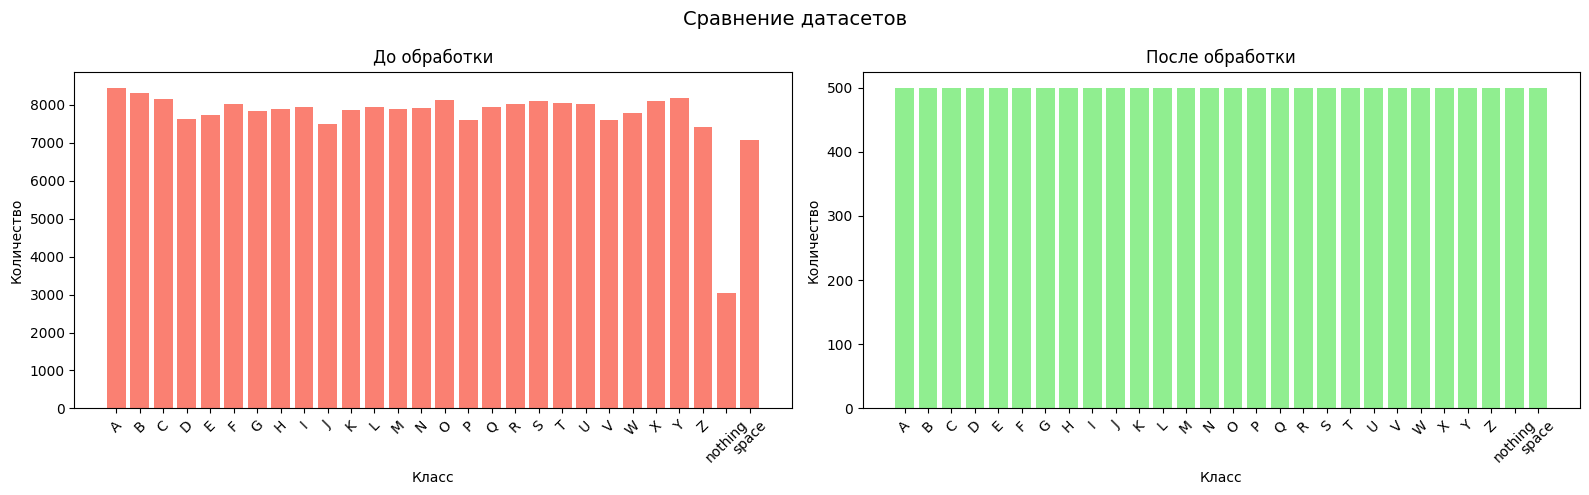


Проверка размера: (224, 224) ✅


In [8]:
# Проверка нового датасета
new_counts = {}
for class_name in sorted(os.listdir(OUTPUT_PATH)):
    class_path = os.path.join(OUTPUT_PATH, class_name)
    if os.path.isdir(class_path):
        images = os.listdir(class_path)
        new_counts[class_name] = len(images)

# Статистика
print('Итоговый датасет:')
print(f'  Классов: {len(new_counts)}')
print(f'  Изображений всего: {sum(new_counts.values())}')
print(f'  На класс: {list(new_counts.values())[0]}')

# График сравнения
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# До
ax1.bar(counts.keys(), counts.values(), color='salmon')
ax1.set_title('До обработки')
ax1.set_xlabel('Класс')
ax1.set_ylabel('Количество')
ax1.tick_params(axis='x', rotation=45)

# После
ax2.bar(new_counts.keys(), new_counts.values(), color='lightgreen')
ax2.set_title('После обработки')
ax2.set_xlabel('Класс')
ax2.set_ylabel('Количество')
ax2.tick_params(axis='x', rotation=45)

plt.suptitle('Сравнение датасетов', fontsize=14)
plt.tight_layout()
plt.show()

# Проверить размер случайного изображения
sample_class = list(new_counts.keys())[0]
sample_img = os.listdir(os.path.join(OUTPUT_PATH, sample_class))[0]
sample_path = os.path.join(OUTPUT_PATH, sample_class, sample_img)

with Image.open(sample_path) as img:
    print(f'\nПроверка размера: {img.size} ✅')

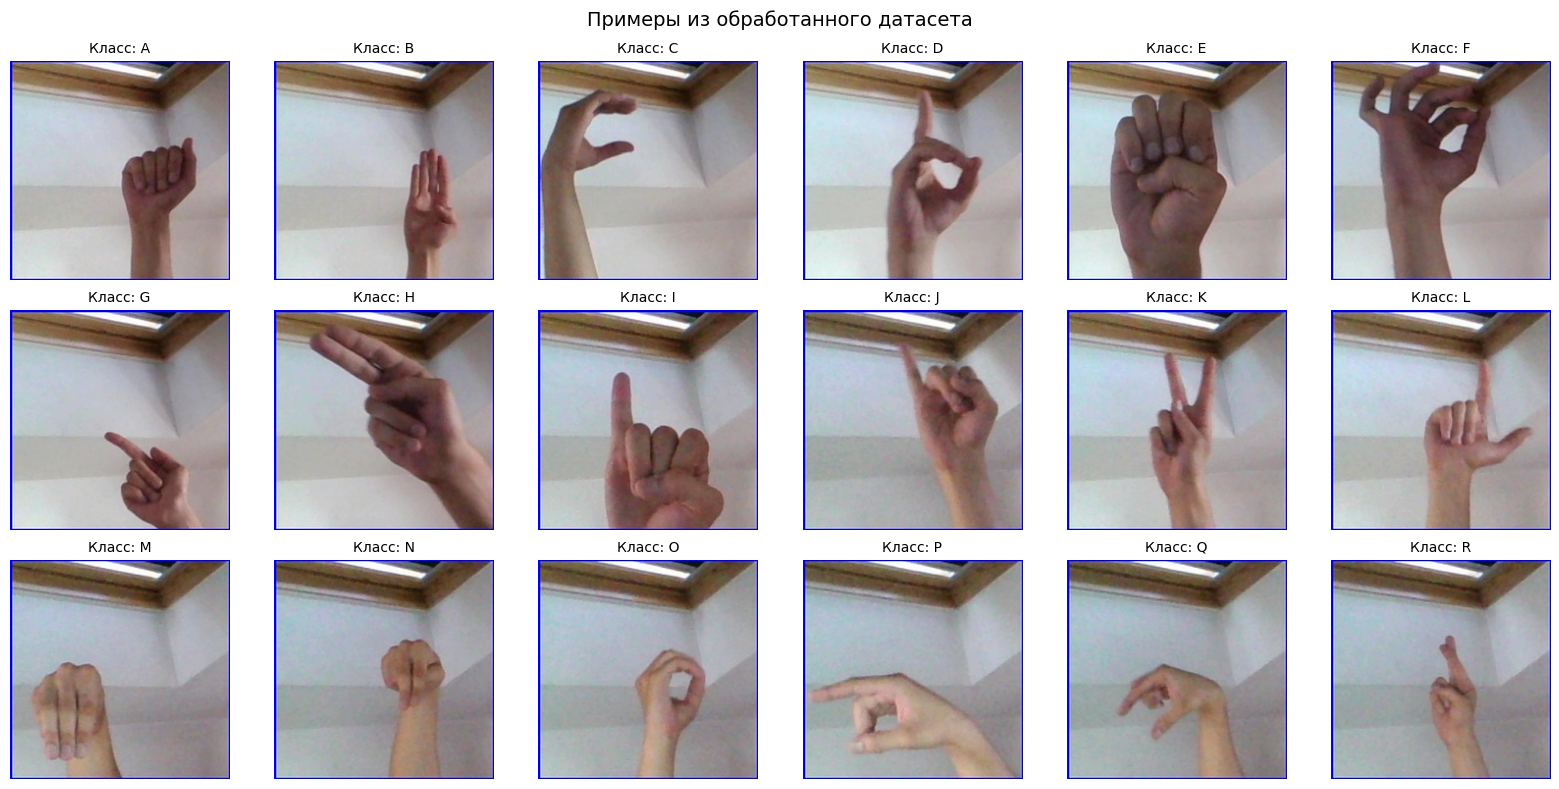

In [9]:
ig, axes = plt.subplots(3, 6, figsize=(16, 8))
axes = axes.flatten()

for idx, class_name in enumerate(sorted(new_counts.keys())[:18]):
    class_path = os.path.join(OUTPUT_PATH, class_name)
    img_file = os.listdir(class_path)[0]
    img_path = os.path.join(class_path, img_file)
    
    img = Image.open(img_path)
    axes[idx].imshow(img)
    axes[idx].set_title(f'Класс: {class_name}', fontsize=10)
    axes[idx].axis('off')

plt.suptitle('Примеры из обработанного датасета', fontsize=14)
plt.tight_layout()
plt.show()

In [10]:
# Обновить путь к датасету
DATASET_PATH = OUTPUT_PATH
print(f'✅ Датасет готов: {DATASET_PATH}')
print(f'   Классов: {len(new_counts)}')
print(f'   Изображений: {sum(new_counts.values())}')

✅ Датасет готов: /work/datasets/tiny
   Классов: 28
   Изображений: 14000
